In [1]:
!pip install pandas numpy matplotlib seaborn plotly yfinance statsmodels scikit-learn prophet


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.1 MB 10.7 MB/s eta 0:00:01
   ------------------- -------------------- 6.0/12.1 MB 15.4 MB/s eta 0:00:01
   ---------------------------------- ----- 10.5/12.1 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 15.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 23.1 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holiday

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

plt.style.use("seaborn-v0_8")


In [3]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01"
)

df.head()


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_20676\2443268982.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2018-01-01,401.864807,407.585208,400.870911,407.585208,9453202
2018-01-02,402.483246,406.193799,400.385024,403.300454,9499419
2018-01-03,404.095551,409.042944,403.322514,408.601196,13507800
2018-01-04,406.525055,407.187662,404.493091,405.575331,9008932
2018-01-05,407.828186,409.440517,406.503001,407.187694,7441284


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1727 entries, 2018-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1727 non-null   float64
 1   (High, RELIANCE.NS)    1727 non-null   float64
 2   (Low, RELIANCE.NS)     1727 non-null   float64
 3   (Open, RELIANCE.NS)    1727 non-null   float64
 4   (Volume, RELIANCE.NS)  1727 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 81.0 KB


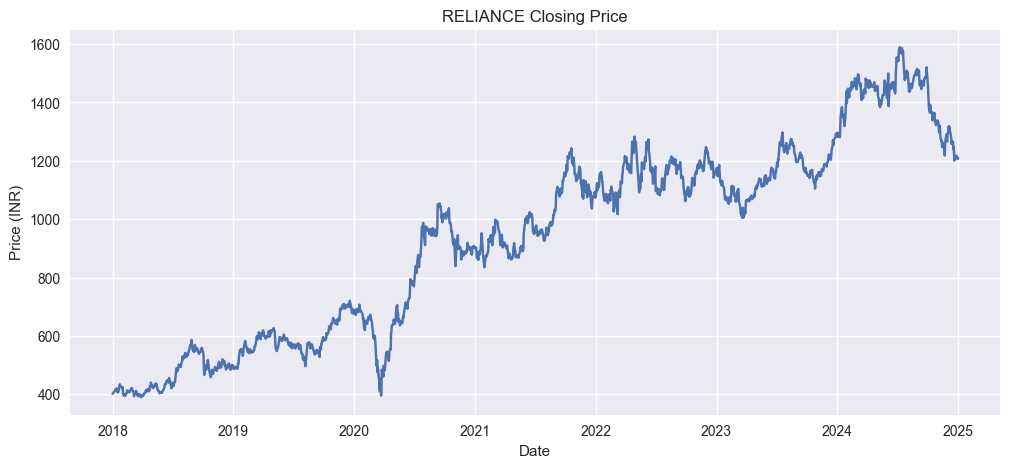

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("RELIANCE Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.show()


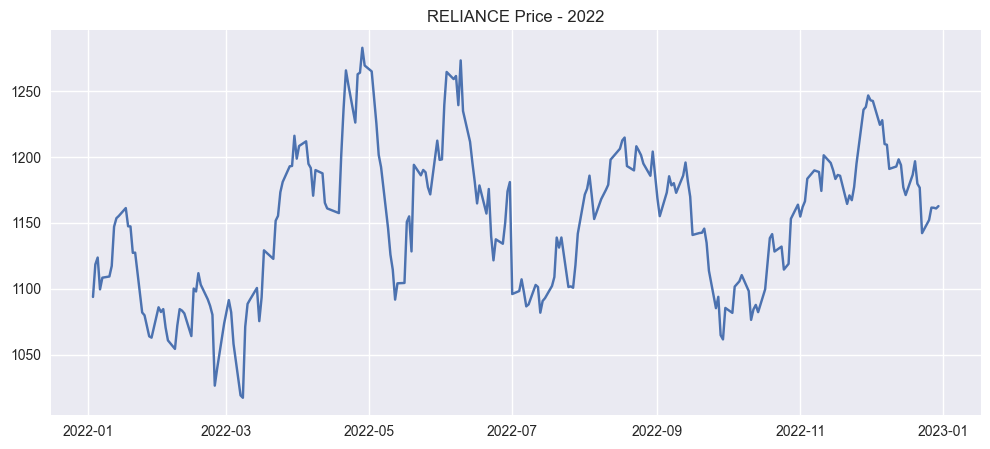

In [6]:
df_2022 = df.loc["2022-01-01":"2022-12-31"]

plt.figure(figsize=(12,5))
plt.plot(df_2022['Close'])
plt.title("RELIANCE Price - 2022")
plt.show()


In [7]:
df.isna().sum()
df = df.ffill()   # forward fill


In [8]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()


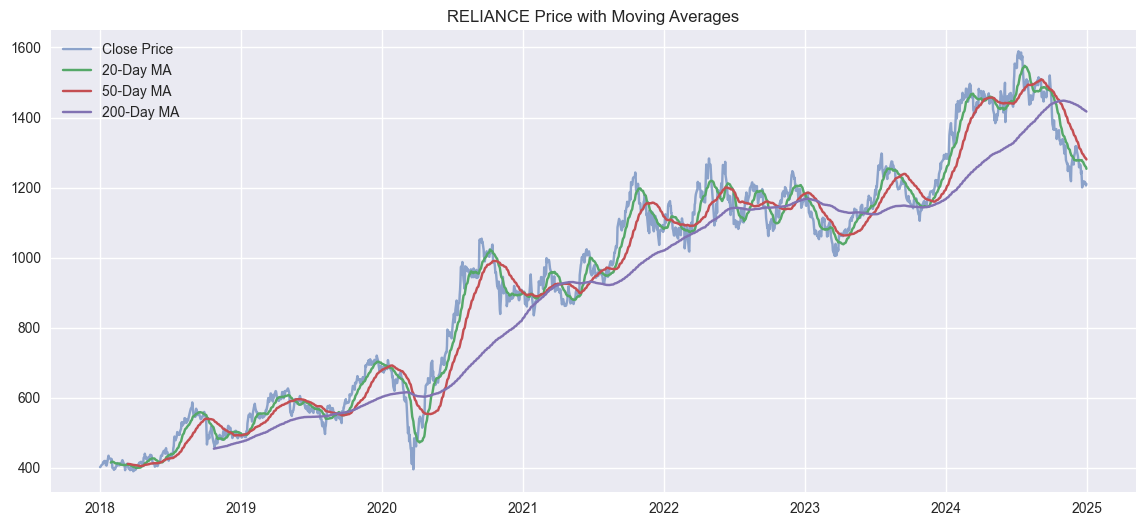

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price', alpha=0.6)
plt.plot(df['MA_20'], label='20-Day MA')
plt.plot(df['MA_50'], label='50-Day MA')
plt.plot(df['MA_200'], label='200-Day MA')

plt.legend()
plt.title("RELIANCE Price with Moving Averages")
plt.show()


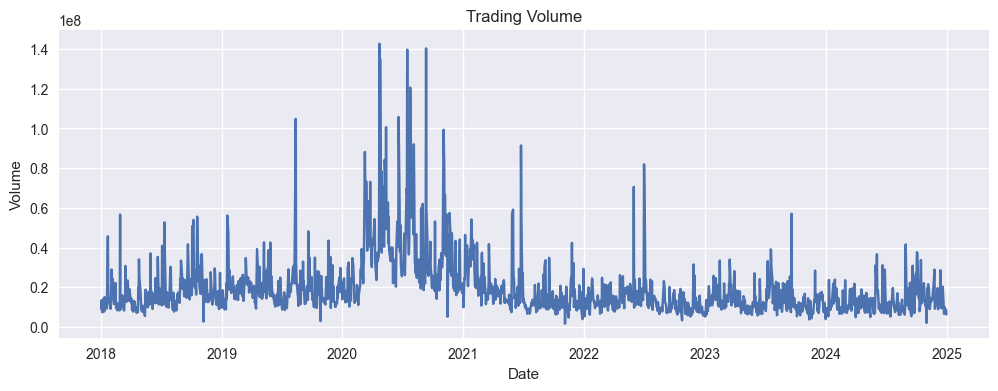

In [15]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['Volume'])
plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()
